In [10]:
import matplotlib.pyplot as plt
import numpy as np
import uproot
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages

#open root file
#df = uproot.open(
 #   "/volatile/clas12/cooperb/SULI/pid_training_test.root:PhysicsEvents"
#).arrays(library="pd")
cols = ["pid", "mc_matching_pid", "p", "theta", "beta", "chi2pid", "rich_RQ", "vz"]
kinematics =["Mx_eKX","Mx_epiX","Mx_epX", "Q2", "W", "y"]

for kin in kinematics:
    cols.append(kin)

df = uproot.open("/volatile/clas12/cooperb/SULI/pid_training_v2.root:PhysicsEvents").arrays(cols, library="pd")
direct ="/work/clas12/CooperBe/Argonne2026/suli2026_pid/figures/ConfusionMatrix/"
allPlots=[]





In [11]:
#creates a list of matching events (excludes events that failed matching)
matched = df[df["mc_matching_pid"] != -9999].copy()
baseline=matched[
(matched["Q2"]>2)&
(matched["W"]>2)&
((matched["y"]>0)&(matched["y"]<0.75))
]
matched=baseline
baseline=matched[
    ((matched["pid"]==321)&(matched["Mx_eKX"]>1.6))|
    ((matched["pid"]==211)&(matched["Mx_epiX"]>1.5))|
    ((matched["pid"]==2212)&(matched["Mx_epX"]>1))]
matched=baseline

In [12]:
fig, ax2 = plt.subplots(figsize=(7, 5)) #plots just the matching pid as a histogram
ax2.hist(matched["mc_matching_pid"].clip(-2212, 2212), bins=100, histtype="step", density=True)
ax2.set_xlabel("mc matching pid"); ax2.set_ylabel("Density");
ax2.set_xticks(np.linspace(-2212, 2212, 10))
fig.tight_layout()
fig.savefig(direct+"matchedPIDs.png", dpi=150)
plt.close(fig)

In [13]:
fig, ax2 = plt.subplots(figsize=(7, 5)) #plots just the True pid as a histogram
ax2.hist(matched["pid"].clip(-2212, 2212), bins=100, histtype="step", density=True)
ax2.set_xlabel("pid"); ax2.set_ylabel("Density");
ax2.set_xticks(np.linspace(2212, 2212, 10))
fig.tight_layout()
fig.savefig(direct+"PIDs.png", dpi=150)
plt.close(fig)


In [14]:
# plots the confusion matrix with all generated particles (K- and Pi- included)
subset = matched[((matched["mc_matching_pid"] == 211) | (matched["mc_matching_pid"] == 321) | (matched["mc_matching_pid"]==2212))& (matched["mc_matching_pid"]!='All')]
top_truths = subset["mc_matching_pid"].value_counts().head(8).index
contam = pd.crosstab(
    subset["pid"],
    subset["mc_matching_pid"].where(subset["mc_matching_pid"].isin(top_truths), other="other"),
    margins=False,
)

print("\nContamination matrix (EB pid × MC-truth pid):") #these three lines are for checking that the matrix is correct
print(contam)
print(contam.shape)

fig, ax2 = plt.subplots(figsize=(7, 5))
ax2.set_xticks([0, 1, 2])
ax2.set_yticks([0, 1, 2, 3])
ax2.set_xticklabels([211, 321, 2212])
ax2.set_yticklabels([-321, -211, 211, 321])
ax2.set_xlabel("True PID")
ax2.set_ylabel("Reconstructed PID")
im = ax2.imshow(contam, cmap='coolwarm', origin='lower')
fig.colorbar(im, ax=ax2)
fig.savefig("figures/ALLGENconfuseMatrix.png", dpi=150)
allPlots.append(fig)
plt.close(fig)


Contamination matrix (EB pid × MC-truth pid):
mc_matching_pid    211    321     2212
pid                                   
211              872289   3606    3284
321               34064  49565    1354
2212              15504   2489  585155
(3, 3)



Contamination matrix (EB pid × MC-truth pid):
mc_matching_pid     211    321    2212      All
pid                                            
211              872289   3606    3284   879179
321               34064  49565    1354    84983
2212              15504   2489  585155   603148
All              921857  55660  589793  1567310
(4, 4)

Contamination matrix (EB pid × MC-truth pid):
mc_matching_pid       211        321        2212
pid                                             
211              99.216314   0.410155   0.373530
321              40.083311  58.323429   1.593260
2212              2.570513   0.412668  97.016818
(3, 3)


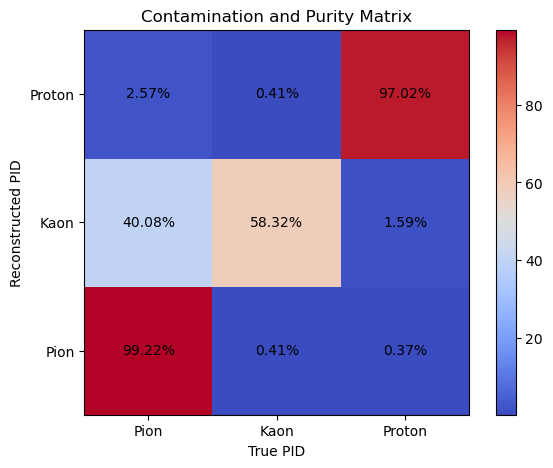

In [15]:
#plots confusion matrix with only kaons, pions and protons
subset = matched[((matched["mc_matching_pid"] == 211) | (matched["mc_matching_pid"] == 321) | (matched["mc_matching_pid"]==2212))]
subset2 = subset[(subset["pid"]!=-211)&(subset["pid"]!=-321)]
top_truths = subset2["mc_matching_pid"].value_counts().head(8).index
contam = pd.crosstab(
    subset2["pid"],
    subset2["mc_matching_pid"].where(subset2["mc_matching_pid"].isin(top_truths), other="other"),
    margins=False,
)
contam2 = pd.crosstab(
    subset2["pid"],
    subset2["mc_matching_pid"].where(subset2["mc_matching_pid"].isin(top_truths), other="other"),
    margins=True,
)
print("\nContamination matrix (EB pid × MC-truth pid):") #these three lines are for checking that the matrix is correct
print(contam2)
print(contam2.shape)


contam = contam.astype(float)
for i in contam.index:
    for j in contam.columns:
        contam.loc[i, j] *= 100/contam2.loc[i, "All"]
print("\nContamination matrix (EB pid × MC-truth pid):") #these three lines are for checking that the matrix is correct
print(contam)
print(contam.shape)

fig, ax2 = plt.subplots(figsize=(7, 5))
ax2.set_xticks([0, 1, 2])
ax2.set_yticks([0, 1, 2])
ax2.set_xticklabels(["Pion", "Kaon", "Proton"])
ax2.set_yticklabels(["Pion", "Kaon", "Proton"])
ax2.set_xlabel("True PID")
ax2.set_ylabel("Reconstructed PID")
ax2.set_title("Contamination and Purity Matrix")
im = ax2.imshow(contam, cmap='coolwarm', origin='lower')
for i in range(contam.shape[0]):
    for j in range(contam.shape[1]):
        ax2.text(
            j, i,
            f"{contam.iloc[i, j]:.2f}%",
            ha="center",
            va="center"
        )
fig.colorbar(im, ax=ax2)
fig.savefig(direct+"PCMatrix.png", dpi=150)
plt.show()
allPlots.append(fig)
plt.close(fig)


Contamination matrix (EB pid × MC-truth pid):
mc_matching_pid     211    321    2212      All
pid                                            
211              872289   3606    3284   879179
321               34064  49565    1354    84983
2212              15504   2489  585155   603148
All              921857  55660  589793  1567310
(4, 4)

Contamination matrix (EB pid × MC-truth pid):
mc_matching_pid      211      321       2212
pid                                         
211              872289.0   3606.0    3284.0
321               34064.0  49565.0    1354.0
2212              15504.0   2489.0  585155.0
(3, 3)

Contamination matrix (EB pid × MC-truth pid):
mc_matching_pid      211      321       2212
pid                                         
211              872289.0   3606.0    3284.0
321               34064.0  49565.0    1354.0
2212              15504.0   2489.0  585155.0
(3, 3)

Contamination matrix (EB pid × MC-truth pid):
mc_matching_pid      211      321       2212
pid     

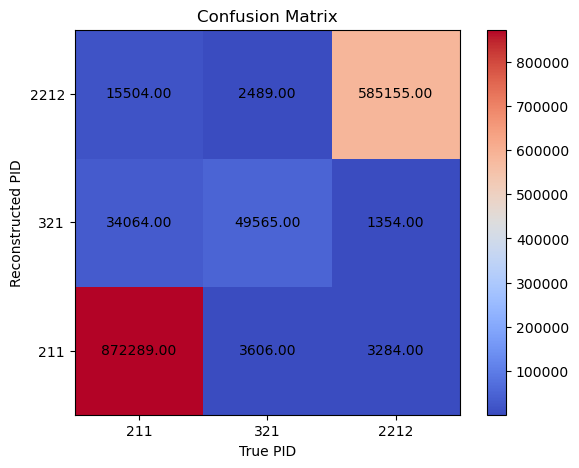

In [7]:
#plots confusion matrix with only kaons, pions and protons
subset = matched[((matched["mc_matching_pid"] == 211) | (matched["mc_matching_pid"] == 321) | (matched["mc_matching_pid"]==2212))]
subset2 = subset[(subset["pid"]!=-211)&(subset["pid"]!=-321)]
top_truths = subset2["mc_matching_pid"].value_counts().head(8).index
contam = pd.crosstab(
    subset2["pid"],
    subset2["mc_matching_pid"].where(subset2["mc_matching_pid"].isin(top_truths), other="other"),
    margins=False,
)
contam2 = pd.crosstab(
    subset2["pid"],
    subset2["mc_matching_pid"].where(subset2["mc_matching_pid"].isin(top_truths), other="other"),
    margins=True,
)
print("\nContamination matrix (EB pid × MC-truth pid):") #these three lines are for checking that the matrix is correct
print(contam2)
print(contam2.shape)


contam = contam.astype(float)
for i in contam.index:
    print("\nContamination matrix (EB pid × MC-truth pid):") #these three lines are for checking that the matrix is correct
    print(contam)
    print(contam.shape)

fig, ax2 = plt.subplots(figsize=(7, 5))
ax2.set_xticks([0, 1, 2])
ax2.set_yticks([0, 1, 2])
ax2.set_xticklabels([211, 321, 2212])
ax2.set_yticklabels([211, 321, 2212])
ax2.set_xlabel("True PID")
ax2.set_ylabel("Reconstructed PID")
ax2.set_title("Confusion Matrix")
im = ax2.imshow(contam, cmap='coolwarm', origin='lower')
for i in range(contam.shape[0]):
    for j in range(contam.shape[1]):
        ax2.text(
            j, i,
            f"{contam.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )
fig.colorbar(im, ax=ax2)
fig.savefig(direct+"confuseMatrixALT.png", dpi=150)
plt.show()
allPlots.append(fig)
plt.close(fig)


Contamination matrix (EB pid × MC-truth pid):
mc_matching_pid     211    321    2212      All
pid                                            
211              872289   3606    3284   879179
321               34064  49565    1354    84983
2212              15504   2489  585155   603148
All              921857  55660  589793  1567310
(4, 4)

Contamination matrix (EB pid × MC-truth pid):
mc_matching_pid       211        321        2212
pid                                             
211              94.623027   6.478620   0.556806
321               3.695150  89.049587   0.229572
2212              1.681823   4.471793  99.213622
(3, 3)


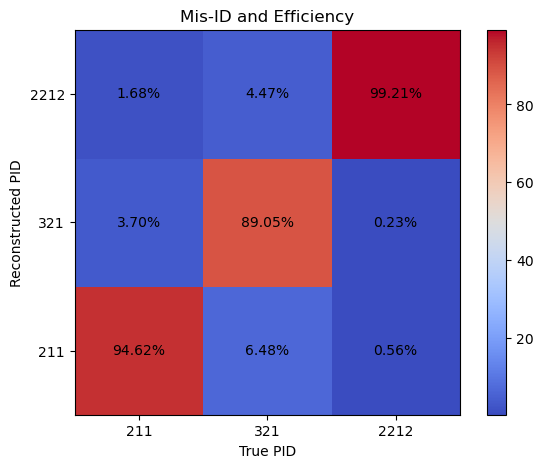

In [8]:
#plots confusion matrix with only kaons, pions and protons
subset = matched[((matched["mc_matching_pid"] == 211) | (matched["mc_matching_pid"] == 321) | (matched["mc_matching_pid"]==2212))]
subset2 = subset[(subset["pid"]!=-211)&(subset["pid"]!=-321)]
top_truths = subset2["mc_matching_pid"].value_counts().head(8).index
contam = pd.crosstab(
    subset2["pid"],
    subset2["mc_matching_pid"].where(subset2["mc_matching_pid"].isin(top_truths), other="other"),
    margins=False,
)
contam2 = pd.crosstab(
    subset2["pid"],
    subset2["mc_matching_pid"].where(subset2["mc_matching_pid"].isin(top_truths), other="other"),
    margins=True,
)
print("\nContamination matrix (EB pid × MC-truth pid):") #these three lines are for checking that the matrix is correct
print(contam2)
print(contam2.shape)


contam = contam.astype(float)
for i in contam.index:
    for j in contam.columns:
        contam.loc[i, j] *= 100/contam2.loc["All", j]
print("\nContamination matrix (EB pid × MC-truth pid):") #these three lines are for checking that the matrix is correct
print(contam)
print(contam.shape)

fig, ax2 = plt.subplots(figsize=(7, 5))
ax2.set_xticks([0, 1, 2])
ax2.set_yticks([0, 1, 2])
ax2.set_xticklabels([211, 321, 2212])
ax2.set_yticklabels([211, 321, 2212])
ax2.set_xlabel("True PID")
ax2.set_ylabel("Reconstructed PID")
ax2.set_title("Mis-ID and Efficiency")
im = ax2.imshow(contam, cmap='coolwarm', origin='lower')
for i in range(contam.shape[0]):
    for j in range(contam.shape[1]):
        ax2.text(
            j, i,
            f"{contam.iloc[i, j]:.2f}%",
            ha="center",
            va="center"
        )
fig.colorbar(im, ax=ax2)
fig.savefig(direct+"EMMatrix.png", dpi=150)
plt.show()
allPlots.append(fig)
plt.close(fig)

In [9]:
with PdfPages("/work/clas12/CooperBe/Argonne2026/suli2026_pid/figures/ConfusionMatrix/" + "AllMatrix.pdf") as pdf:
    for plot in allPlots:
        pdf.savefig(plot)